# Ноутбук 00b — EDA: STL-декомпозиция, структурные сдвиги, динамика onpromotion, описательная статистика
**Подраздел 2.2 ПЗ — Визуальный и статистический анализ**

Запускать после 00_eda_dataset_overview.ipynb.
Артефакты: `reports/figures/fig_stl_decomposition.png`, `fig_promo_dynamics.png`, `fig_structural_breaks.png`, `reports/tables/table_descriptive_stats.csv`

In [1]:
# ── Ячейка 0: Импорты и загрузка данных (повторно из 00) ────────────────────────
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import STL

from src.config import (
    DATA_RAW, FIGURES, TABLES,
    DATE_COL, STORE_COL, FAMILY_COL, TRAIN_CUTOFF
)
from src.io.preprocess import load_raw_files, fill_oil_gaps

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.family": "DejaVu Sans",
})

data = load_raw_files()
train = data["train"]
train[DATE_COL] = pd.to_datetime(train[DATE_COL])

# Недельные суммарные продажи (используется во всех ячейках)
weekly_sales = (
    train.groupby(DATE_COL)["sales"]
    .sum()
    .resample("W-MON")
    .sum()
)
print(f"Загружено: {len(weekly_sales)} недельных наблюдений, от {weekly_sales.index[0].date()} до {weekly_sales.index[-1].date()}")

Загружено: 242 недельных наблюдений, от 2013-01-07 до 2017-08-21


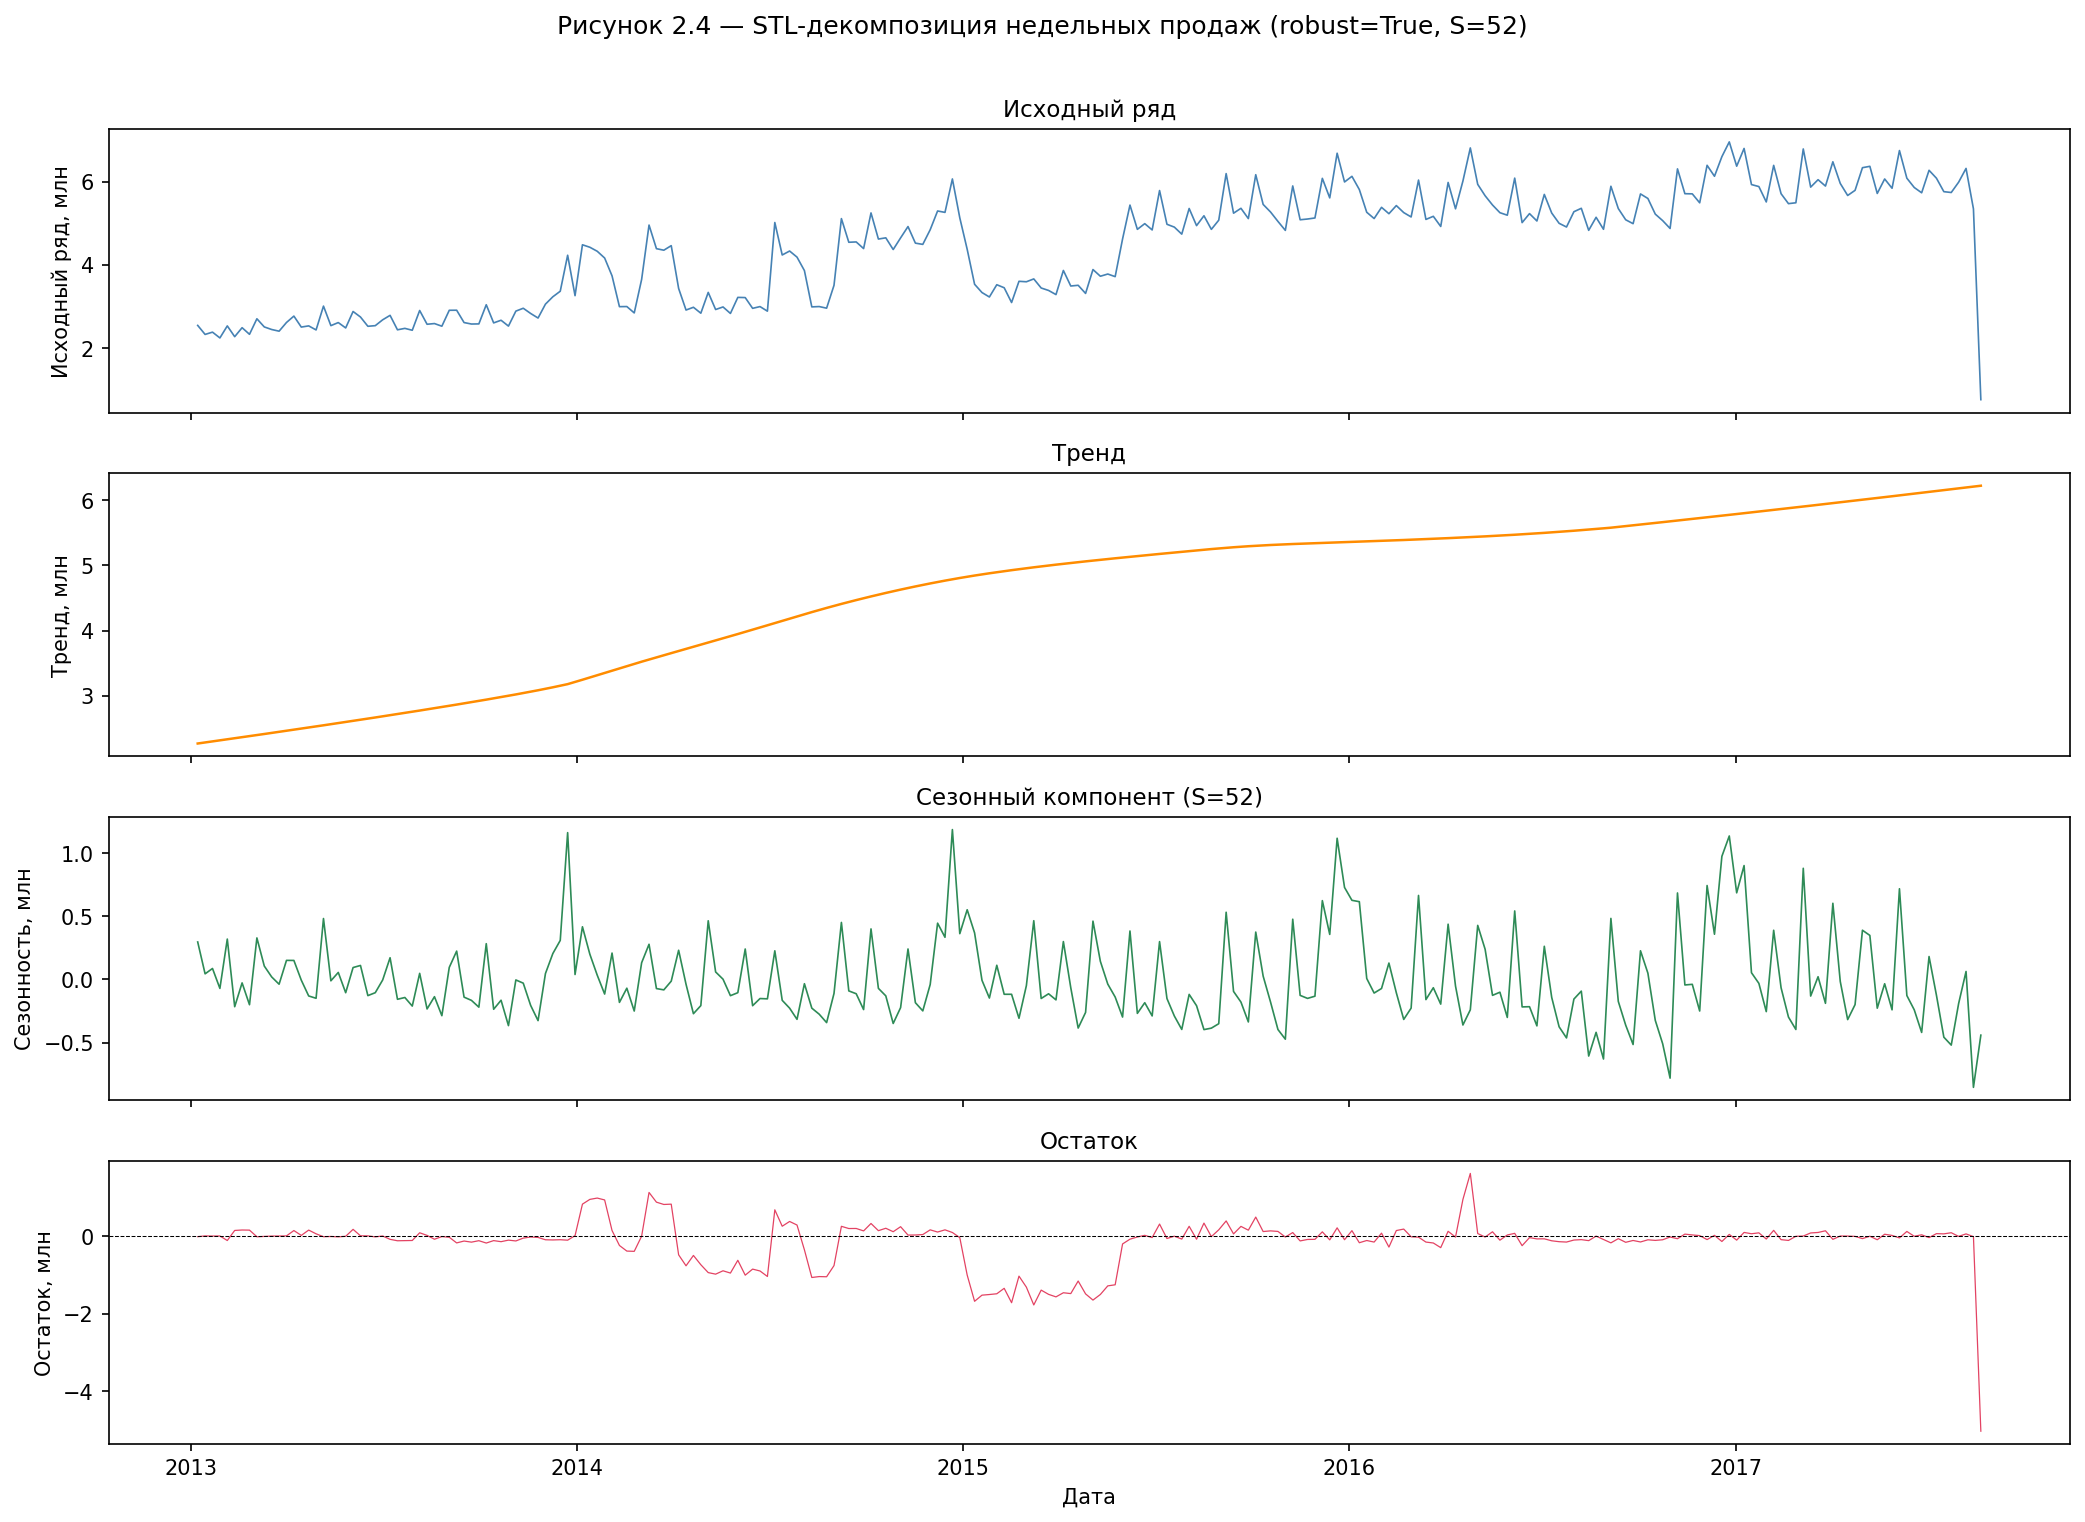

Доля дисперсии — тренд:    79.7 %
Доля дисперсии — сезон.: 6.6 %
Доля дисперсии — остат.:  20.8 %
Сохранено: fig_stl_decomposition.png


In [2]:
# ── Ячейка 1: STL-декомпозиция → fig_stl_decomposition.png (2.2.2) ────────────────
# STL (Seasonal and Trend decomposition using Loess) разлагает ряд на 3 компоненты:
# trend (тренд), seasonal (сезонность, S=52), resid (остаток).
# robust=True снижает влияние выбросов (землетрясение 2016) на оценку тренда.

stl = STL(weekly_sales.dropna(), period=52, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly_sales.index, weekly_sales.values / 1e6, color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Исходный ряд, млн")
axes[0].set_title("Исходный ряд")

axes[1].plot(weekly_sales.index, res.trend / 1e6, color="darkorange", linewidth=1.2)
axes[1].set_ylabel("Тренд, млн")
axes[1].set_title("Тренд")

axes[2].plot(weekly_sales.index, res.seasonal / 1e6, color="seagreen", linewidth=0.8)
axes[2].set_ylabel("Сезонность, млн")
axes[2].set_title("Сезонный компонент (S=52)")

axes[3].plot(weekly_sales.index, res.resid / 1e6, color="crimson", linewidth=0.6, alpha=0.8)
axes[3].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[3].set_ylabel("Остаток, млн")
axes[3].set_title("Остаток")
axes[3].set_xlabel("Дата")

fig.suptitle("Рисунок 2.4 — STL-декомпозиция недельных продаж (robust=True, S=52)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "fig_stl_decomposition.png", bbox_inches="tight")
plt.show()

# Выводим долю вариации по компонентам
total_var = np.var(weekly_sales.dropna())
print(f"Доля дисперсии — тренд:    {np.var(res.trend)/total_var*100:.1f} %")
print(f"Доля дисперсии — сезон.: {np.var(res.seasonal)/total_var*100:.1f} %")
print(f"Доля дисперсии — остат.:  {np.var(res.resid)/total_var*100:.1f} %")
print("Сохранено: fig_stl_decomposition.png")

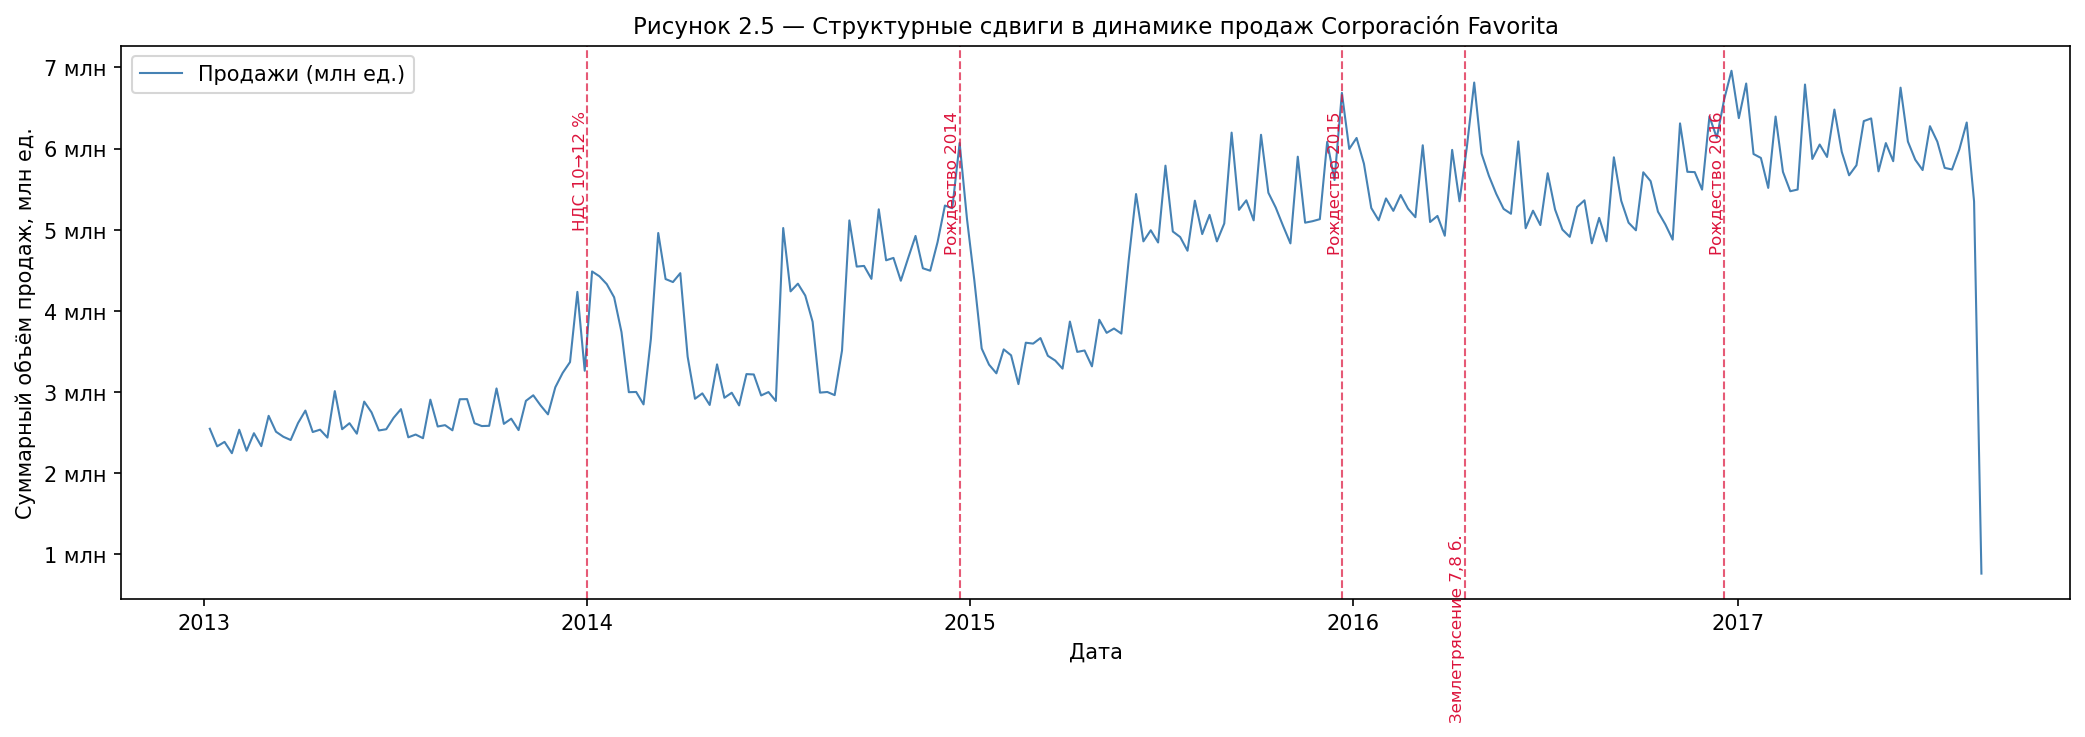

Сохранено: fig_structural_breaks.png


In [3]:
# ── Ячейка 2: Структурные сдвиги → fig_structural_breaks.png (2.2.3) ─────────────────
# Три документированных события в истории Favorita:
# 1. 01.01.2014 — повышение НДС с 10 % до 12 % (снижение покупательной активности)
# 2. 16.04.2016 — землетрясение 7,8 балла (провал в логистике, аномальный всплеск покупок)
# 3. Декабрь: ежегодный рождественский пик

events = {
    "2014-01-01": ("НДС 10→12 %",         "top"),
    "2016-04-16": ("Землетрясение 7,8 б.", "bottom"),
    "2014-12-22": ("Рождество 2014",     "top"),
    "2015-12-21": ("Рождество 2015",     "top"),
    "2016-12-19": ("Рождество 2016",     "top"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_sales.index, weekly_sales.values / 1e6,
        color="steelblue", linewidth=1, label="Продажи (млн ед.)")

# Наносим вертикальные линии и подписи для каждого события
y_max = weekly_sales.max() / 1e6
y_min = weekly_sales.min() / 1e6
for date_str, (label, pos) in events.items():
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    y_txt = y_max * 0.93 if pos == "top" else y_min + (y_max - y_min) * 0.08
    ax.annotate(label, xy=(dt, y_txt), fontsize=8, color="crimson",
                rotation=90, va="top", ha="right")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} млн"))
ax.set_xlabel("Дата")
ax.set_ylabel("Суммарный объём продаж, млн ед.")
ax.set_title("Рисунок 2.5 — Структурные сдвиги в динамике продаж Corporación Favorita")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "fig_structural_breaks.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_structural_breaks.png")

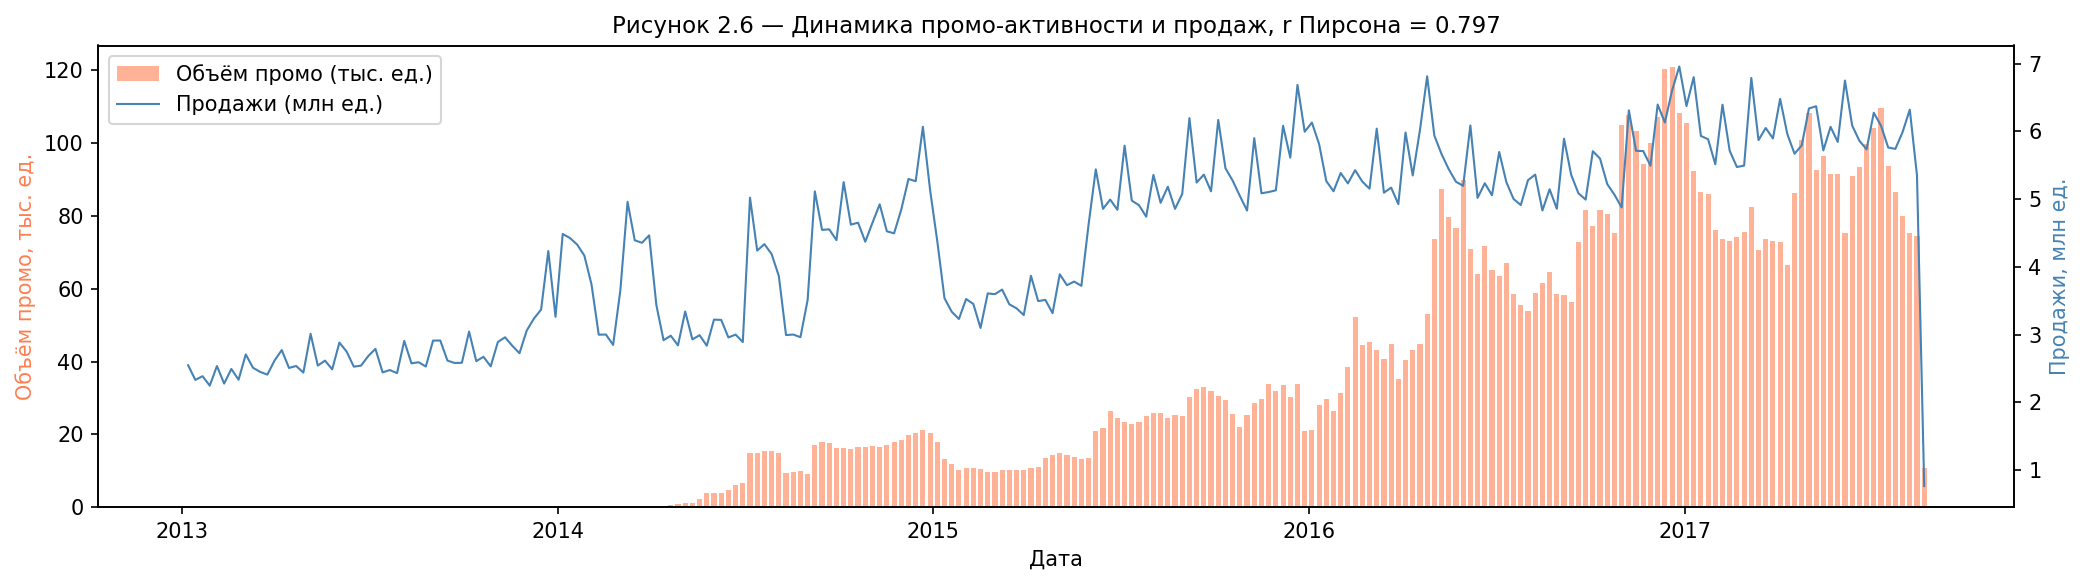

Корреляция Пирсона (promo_weekly, sales_weekly): 0.797
Сохранено: fig_promo_dynamics.png


In [4]:
# ── Ячейка 3: Динамика onpromotion во времени → fig_promo_dynamics.png (2.2.5) ──────────
# fig_promo_by_family.png показывает суммарный рейтинг по семействам.
# Эта ячейка строит линейный график недельной динамики промо-активности.

weekly_promo = (
    train.groupby(DATE_COL)["onpromotion"]
    .sum()
    .resample("W-MON")
    .sum()
)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(weekly_promo.index, weekly_promo.values / 1e3,
        width=5, color="coral", alpha=0.6, label="Объём промо (тыс. ед.)")
ax2.plot(weekly_sales.index, weekly_sales.values / 1e6,
         color="steelblue", linewidth=1, label="Продажи (млн ед.)")

ax1.set_ylabel("Объём промо, тыс. ед.", color="coral")
ax2.set_ylabel("Продажи, млн ед.", color="steelblue")
ax1.set_xlabel("Дата")

corr_promo = weekly_promo.corr(weekly_sales.reindex(weekly_promo.index))
ax1.set_title(f"Рисунок 2.6 — Динамика промо-активности и продаж, r Пирсона = {corr_promo:.3f}")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "fig_promo_dynamics.png", bbox_inches="tight")
plt.show()
print(f"Корреляция Пирсона (promo_weekly, sales_weekly): {corr_promo:.3f}")
print("Сохранено: fig_promo_dynamics.png")

In [5]:
# ── Ячейка 4: Описательная статистика → table_descriptive_stats.csv (2.2.6) ──────────────
# Собираем describe() по четырём ключевым переменным: sales, onpromotion, oil, transactions.
# Недельные агрегаты используются для согласованности с уровнем моделирования.

# ─ 1. sales_weekly (суммарный недельный объём по всем магазинам и семействам)
sales_weekly_flat = (
    train.groupby([DATE_COL, STORE_COL, FAMILY_COL])["sales"]
    .sum()
    .groupby(level=[DATE_COL, STORE_COL, FAMILY_COL])
    .sum()
    .reset_index()["sales"]
)

# ─ 2. onpromotion_weekly
promo_weekly_flat = (
    train.groupby([DATE_COL, STORE_COL, FAMILY_COL])["onpromotion"]
    .sum()
    .reset_index()["onpromotion"]
)

# ─ 3. oil_price (fill gaps, then weekly mean)
oil_raw = data["oil"].copy()
oil_raw[DATE_COL] = pd.to_datetime(oil_raw[DATE_COL])
oil_filled = (
    oil_raw.set_index(DATE_COL).resample("D")["dcoilwtico"]
    .mean().ffill().bfill()
)
oil_weekly_vals = oil_filled.resample("W-MON").mean().dropna()

# ─ 4. transactions_weekly
tx = data["transactions"].copy()
tx[DATE_COL] = pd.to_datetime(tx[DATE_COL])
tx_weekly_vals = (
    tx.groupby([DATE_COL, STORE_COL])["transactions"]
    .sum()
    .reset_index()["transactions"]
)

# ─ Сборка describe() с переводом названий
desc_rows = {}
for name, series in [
    ("Продажи за неделю, ед.",      sales_weekly_flat),
    ("Объём промо за неделю, ед.",   promo_weekly_flat),
    ("Цена нефти WTI, USD",            oil_weekly_vals),
    ("Транзакции магазина за неделю", tx_weekly_vals),
]:
    d = series.describe(percentiles=[0.25, 0.5, 0.75])
    desc_rows[name] = {
        "Количество наблюдений": int(d["count"]),
        "Среднее": round(d["mean"], 2),
        "Ст. откл.": round(d["std"], 2),
        "Минимум": round(d["min"], 2),
        "Квартиль 25 %": round(d["25%"], 2),
        "Медиана": round(d["50%"], 2),
        "Квартиль 75 %": round(d["75%"], 2),
        "Максимум": round(d["max"], 2),
    }

desc_df = pd.DataFrame(desc_rows).T
desc_df.index.name = "Переменная"
desc_df.to_csv(TABLES / "table_descriptive_stats.csv")

print("Таблица 2.3 — Описательная статистика ключевых переменных")
display(desc_df)
print("\nСохранено: table_descriptive_stats.csv")

Таблица 2.3 — Описательная статистика ключевых переменных


,Количество наблюдений,Среднее,Ст. откл.,Минимум,Квартиль 25 %,Медиана,Квартиль 75 %,Максимум
Переменная,,,,,,,,
"Продажи за неделю, ед.",3000888.0,357.78,1102.00,0.00,0.00,11.00,195.85,124717.00
"Объём промо за неделю, ед.",3000888.0,2.60,12.22,0.00,0.00,0.00,0.00,741.00
"Цена нефти WTI, USD",244.0,67.67,25.64,28.42,46.27,53.24,95.42,109.42
Транзакции магазина за неделю,83488.0,1694.60,963.29,5.00,1046.00,1393.00,2079.00,8359.00



Сохранено: table_descriptive_stats.csv


Граница аномалий (нижняя): -6.9 млн
Граница аномалий (верхняя): 15.4 млн
Обнаружено недель: 0
Series([], Freq: W-MON, Name: sales, dtype: float64)


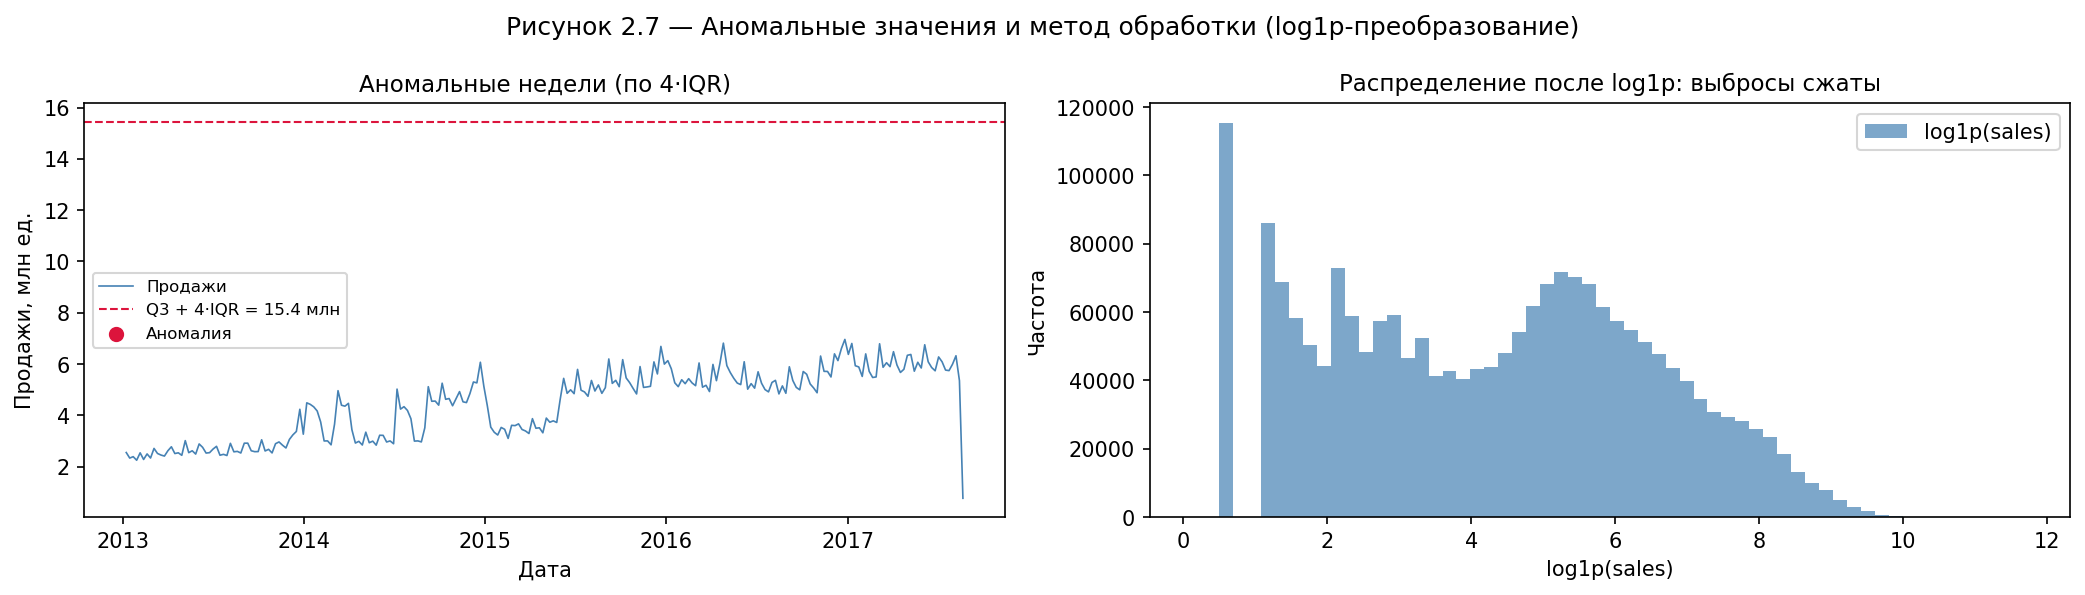

Сохранено: fig_anomalies_log1p.png


In [6]:
# ── Ячейка 5: Аномальные значения — визуализация (2.2.4) ─────────────────────
# Аномалии определяются как отступление от медианы > 4*IQR (более консервативно, чем 1.5*IQR,
# поскольку продажи Favorita имеют тяжёлый хвост).
# Метод обработки: логарифмическое преобразование целевой переменной (log1p) сжимает выбросы.

# Используем недельный ряд суммарных продаж
q1 = weekly_sales.quantile(0.25)
q3 = weekly_sales.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 4 * iqr
lower_fence = q1 - 4 * iqr
anomalies = weekly_sales[(weekly_sales > upper_fence) | (weekly_sales < lower_fence)]
print(f"Граница аномалий (нижняя): {lower_fence/1e6:.1f} млн")
print(f"Граница аномалий (верхняя): {upper_fence/1e6:.1f} млн")
print(f"Обнаружено недель: {len(anomalies)}")
print(anomalies)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Левый: ряд с отметками аномалий
axes[0].plot(weekly_sales.index, weekly_sales.values / 1e6,
             color="steelblue", linewidth=0.8, label="Продажи")
axes[0].axhline(upper_fence / 1e6, color="crimson", linestyle="--",
                linewidth=1, label=f"Q3 + 4·IQR = {upper_fence/1e6:.1f} млн")
axes[0].scatter(anomalies.index, anomalies.values / 1e6,
                color="crimson", zorder=5, s=40, label="Аномалия")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}"))
axes[0].set_ylabel("Продажи, млн ед.")
axes[0].set_xlabel("Дата")
axes[0].set_title("Аномальные недели (по 4·IQR)")
axes[0].legend(fontsize=8)

# Правый: сравнение log1p всех ненулевых продаж до и после преобразования
sales_nz = train.loc[train["sales"] > 0, "sales"]
axes[1].hist(np.log1p(sales_nz), bins=60, color="steelblue",
             alpha=0.7, label="log1p(sales)")
axes[1].set_xlabel("log1p(sales)")
axes[1].set_ylabel("Частота")
axes[1].set_title("Распределение после log1p: выбросы сжаты")
axes[1].legend()

fig.suptitle("Рисунок 2.7 — Аномальные значения и метод обработки (log1p-преобразование)")
plt.tight_layout()
plt.savefig(FIGURES / "fig_anomalies_log1p.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_anomalies_log1p.png")

In [7]:
print("\n=== Ноутбук 00b выполнен полностью ===")
print("Артефакты:")
print("  reports/figures/fig_stl_decomposition.png   — Рис. 2.4")
print("  reports/figures/fig_structural_breaks.png   — Рис. 2.5")
print("  reports/figures/fig_promo_dynamics.png      — Рис. 2.6")
print("  reports/figures/fig_anomalies_log1p.png     — Рис. 2.7")
print("  reports/tables/table_descriptive_stats.csv  — Табл. 2.3")


=== Ноутбук 00b выполнен полностью ===
Артефакты:
  reports/figures/fig_stl_decomposition.png   — Рис. 2.4
  reports/figures/fig_structural_breaks.png   — Рис. 2.5
  reports/figures/fig_promo_dynamics.png      — Рис. 2.6
  reports/figures/fig_anomalies_log1p.png     — Рис. 2.7
  reports/tables/table_descriptive_stats.csv  — Табл. 2.3
